In [1]:

# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from datetime import datetime
import warnings
from collections import defaultdict

print("Libraries imported.")


Libraries imported.


In [2]:

# --- Setup Project Path ---
# Add the project root directory ('AgenticFC888') to the Python path
# Assumes this notebook is in 'AgenticFC888/models/notebooks/'
try:
    NOTEBOOK_DIR = os.path.abspath(os.path.dirname(''))
    PROJECT_ROOT = os.path.dirname(os.path.dirname(NOTEBOOK_DIR))
    print(f"Project Root detected as: {PROJECT_ROOT}")
    if PROJECT_ROOT not in sys.path:
        print(f"Adding project root to sys.path.")
        sys.path.append(PROJECT_ROOT)
except NameError:
     PROJECT_ROOT = '/Users/barroca888/Downloads/Agenticfc/AgenticFC888' # <-- SET MANUALLY IF NEEDED
     print(f"Using manually set PROJECT_ROOT: {PROJECT_ROOT}")
     if PROJECT_ROOT not in sys.path: sys.path.append(PROJECT_ROOT)
except Exception as e:
    print(f"Error setting up project path: {e}")


Project Root detected as: /Users/barroca888/Downloads/Agenticfc/AgenticFC888
Adding project root to sys.path.


In [3]:


# --- Configuration ---

# --- CHOOSE WHICH PREDICTION FILE TO USE ---
# EVAL_CSV_FILENAME = 'predictions_eval_no_odds.csv'
EVAL_CSV_FILENAME = 'predictions_with_odds_latest.csv' # Or predictions_with_odds_latest.csv etc.

# --- DEFINE YOUR PARLAY STRATEGY PARAMETERS ---
PARLAY_MIN_PROBABILITY = 0.65  # Minimum probability for a leg to be considered
PARLAY_MAX_RANK = 1           # Only consider Rank 1 predictions? (Set to 1, 2, 3 etc.)
PARLAY_MIN_LEGS = 2           # Minimum number of qualifying legs needed to form a parlay
PARLAY_MAX_LEGS = 5           # Maximum number of legs allowed in one parlay (optional)
# Optional: Filter by specific outcome types
# PARLAY_ALLOWED_OUTCOMES = ['[Over 1.5]', '[Home Win or Draw]', '[Under 3.5]'] # Example, set to None to allow all
PARLAY_ALLOWED_OUTCOMES = None

# --- Path to the prediction file ---
EVAL_CSV_PATH = os.path.join(PROJECT_ROOT, 'models', 'data', 'outputs', 'predictions', EVAL_CSV_FILENAME)

print(f"Parlay Strategy:")
print(f"- Min Probability per Leg: {PARLAY_MIN_PROBABILITY}")
print(f"- Max Rank per Leg: {PARLAY_MAX_RANK}")
print(f"- Min Legs per Parlay: {PARLAY_MIN_LEGS}")
print(f"- Max Legs per Parlay: {PARLAY_MAX_LEGS}")
print(f"- Allowed Outcomes: {'Any' if PARLAY_ALLOWED_OUTCOMES is None else PARLAY_ALLOWED_OUTCOMES}")
print(f"\nAttempting to load evaluation data from: {EVAL_CSV_PATH}")

# --- Load Data ---
try:
    df_eval = pd.read_csv(EVAL_CSV_PATH)
    print(f"\nData loaded successfully. Shape: {df_eval.shape}")

    # --- CRUCIAL: Check and Convert Date Column ---
    if 'Date' not in df_eval.columns:
        raise ValueError("CRITICAL ERROR: 'Date' column not found in the CSV. Modify predict_pipeline.py to include it.")
    df_eval['Date'] = pd.to_datetime(df_eval['Date'])
    print("'Date' column converted to datetime.")

    print("Sample Data:")
    display(df_eval.head())
except FileNotFoundError:
    print(f"ERROR: Evaluation file not found at {EVAL_CSV_PATH}")
    raise SystemExit("Evaluation file missing.")
except ValueError as ve:
    print(ve)
    raise SystemExit("Date column issue.")
except Exception as e:
    print(f"An error occurred loading or processing the CSV: {e}")
    raise SystemExit("Failed to load data.")


Parlay Strategy:
- Min Probability per Leg: 0.65
- Max Rank per Leg: 1
- Min Legs per Parlay: 2
- Max Legs per Parlay: 5
- Allowed Outcomes: Any

Attempting to load evaluation data from: /Users/barroca888/Downloads/Agenticfc/AgenticFC888/models/data/outputs/predictions/predictions_with_odds_latest.csv

Data loaded successfully. Shape: (874648, 10)
'Date' column converted to datetime.
Sample Data:


,MatchID,HomeTeam,AwayTeam,Rank,Outcome,Probability,Date,FTHG,FTAG,FTR
0,20100730_StandardLiege_ZulteWaregem,Standard Liege,Zulte Waregem,1,[Over 1.5],0.754168,2010-07-30,1,1,D
1,20100730_StandardLiege_ZulteWaregem,Standard Liege,Zulte Waregem,2,[Home Win or Away Win],0.745678,2010-07-30,1,1,D
2,20100730_StandardLiege_ZulteWaregem,Standard Liege,Zulte Waregem,3,[Under 3.5],0.710635,2010-07-30,1,1,D
3,20100730_StandardLiege_ZulteWaregem,Standard Liege,Zulte Waregem,4,[Home Win or Draw],0.692215,2010-07-30,1,1,D
4,20100730_StandardLiege_ZulteWaregem,Standard Liege,Zulte Waregem,5,[Goals 2-4],0.614736,2010-07-30,1,1,D


In [4]:


# Define the function to check correctness (same as before)
def is_prediction_correct(row):
    """Checks if a prediction row matches the actual outcome."""
    outcome = row['Outcome']
    fthg = row['FTHG']
    ftag = row['FTAG']
    ftr = row['FTR']
    if pd.isna(fthg) or pd.isna(ftag) or pd.isna(ftr): return np.nan
    try: fthg, ftag = float(fthg), float(ftag)
    except: return np.nan
    total_goals = fthg + ftag

    # Singles
    if outcome == "[Home Win]": return ftr == 'H'
    if outcome == "[Draw]": return ftr == 'D'
    if outcome == "[Away Win]": return ftr == 'A'
    if outcome == "[Home Win or Draw]": return ftr in ['H', 'D']
    if outcome == "[Away Win or Draw]": return ftr in ['A', 'D']
    if outcome == "[Home Win or Away Win]": return ftr in ['H', 'A']
    if outcome == "[Over 0.5]": return total_goals > 0.5
    if outcome == "[Under 0.5]": return total_goals < 0.5
    if outcome == "[Over 1.5]": return total_goals > 1.5
    if outcome == "[Under 1.5]": return total_goals < 1.5
    if outcome == "[Over 2.5]": return total_goals > 2.5
    if outcome == "[Under 2.5]": return total_goals < 2.5
    if outcome == "[Over 3.5]": return total_goals > 3.5
    if outcome == "[Under 3.5]": return total_goals < 3.5
    if outcome == "[Over 4.5]": return total_goals > 4.5
    if outcome == "[Under 4.5]": return total_goals < 4.5
    if outcome == "[BTTS Yes]": return fthg > 0 and ftag > 0
    if outcome == "[BTTS No]": return fthg == 0 or ftag == 0
    if outcome == "[Goals 0-1]": return total_goals <= 1
    if outcome == "[Goals 2-3]": return total_goals in [2, 3]
    if outcome == "[Goals 2-4]": return total_goals in [2, 3, 4]
    if outcome == "[Goals 3+]": return total_goals >= 3

    # Duals
    if ' + ' in outcome:
        temp_row = row.copy(); parts = outcome[1:-1].split(' + ')
        if len(parts) == 2:
            part1_outcome, part2_outcome = "[" + parts[0] + "]", "[" + parts[1] + "]"
            temp_row['Outcome'] = part1_outcome; correct1 = is_prediction_correct(temp_row)
            temp_row['Outcome'] = part2_outcome; correct2 = is_prediction_correct(temp_row)
            if isinstance(correct1, bool) and isinstance(correct2, bool): return correct1 and correct2
            else: return np.nan
    return False

print("Evaluation function defined.")

Evaluation function defined.


In [5]:

# --- Apply Evaluation ---
print("Applying evaluation logic to DataFrame...")
if 'df_eval' in locals() and isinstance(df_eval, pd.DataFrame):
    # Check if 'IsCorrect' already exists, maybe from previous run
    if 'IsCorrect' not in df_eval.columns:
        df_eval['IsCorrect'] = df_eval.apply(is_prediction_correct, axis=1)
        print("Evaluation complete. 'IsCorrect' column added.")
    else:
        print("'IsCorrect' column already exists.")
    display(df_eval[['Date', 'Rank', 'Outcome', 'Probability', 'FTHG', 'FTAG', 'FTR', 'IsCorrect']].head())
else:
    print("ERROR: df_eval DataFrame not found. Run previous cells.")



Applying evaluation logic to DataFrame...
Evaluation complete. 'IsCorrect' column added.


,Date,Rank,Outcome,Probability,FTHG,FTAG,FTR,IsCorrect
0,2010-07-30,1,[Over 1.5],0.754168,1,1,D,True
1,2010-07-30,2,[Home Win or Away Win],0.745678,1,1,D,False
2,2010-07-30,3,[Under 3.5],0.710635,1,1,D,True
3,2010-07-30,4,[Home Win or Draw],0.692215,1,1,D,True
4,2010-07-30,5,[Goals 2-4],0.614736,1,1,D,True


In [6]:


print("\n--- Simulating Daily Parlays ---")

parlay_results = []

if 'df_eval' in locals() and 'IsCorrect' in df_eval.columns:
    # Ensure data is sorted by date for logical processing
    df_eval_sorted = df_eval.sort_values(by='Date').copy()
    df_evaluated = df_eval_sorted.dropna(subset=['IsCorrect', 'Probability', 'Rank']).copy() # Drop rows missing needed info

    # Group by Date
    daily_groups = df_evaluated.groupby(df_evaluated['Date'].dt.date) # Group by calendar date

    print(f"Processing {len(daily_groups)} days...")

    for date, daily_preds in daily_groups:
        # Apply Parlay Selection Strategy for this day
        selected_legs = daily_preds[
            (daily_preds['Rank'] <= PARLAY_MAX_RANK) &
            (daily_preds['Probability'] >= PARLAY_MIN_PROBABILITY)
        ].copy()

        # Apply outcome filter if specified
        if PARLAY_ALLOWED_OUTCOMES is not None:
            selected_legs = selected_legs[selected_legs['Outcome'].isin(PARLAY_ALLOWED_OUTCOMES)]

        # Ensure one prediction per match (take highest rank, then highest prob if ties)
        selected_legs = selected_legs.sort_values(by=['Rank', 'Probability'], ascending=[True, False])
        selected_legs = selected_legs.drop_duplicates(subset=['MatchID'], keep='first')

        # Apply max legs limit
        if len(selected_legs) > PARLAY_MAX_LEGS:
            selected_legs = selected_legs.head(PARLAY_MAX_LEGS) # Keep top N legs based on sort order

        # Check if minimum number of legs is met
        if len(selected_legs) >= PARLAY_MIN_LEGS:
            # This day forms a parlay paper
            parlay_won = selected_legs['IsCorrect'].all() # Paper wins only if ALL legs are True
            parlay_prob = selected_legs['Probability'].prod() # Combined probability (assuming independence)
            num_legs = len(selected_legs)

            parlay_results.append({
                'Date': date,
                'NumLegs': num_legs,
                'ParlayWon': parlay_won,
                'ParlayProbability': parlay_prob,
                'Legs': selected_legs[['MatchID', 'HomeTeam', 'AwayTeam', 'Outcome', 'Probability', 'IsCorrect']].to_dict('records')
            })

    print(f"Simulation complete. Generated {len(parlay_results)} parlay papers.")

else:
    print("ERROR: df_eval or 'IsCorrect' column not found. Run previous cells.")



--- Simulating Daily Parlays ---
Processing 4641 days...
Simulation complete. Generated 4384 parlay papers.



--- Parlay Performance Analysis ---


,Date,NumLegs,ParlayWon,ParlayProbability,Legs
0,2010-07-31,3,False,0.422322,"[{'MatchID': '20100731_KVCWesterlo_Gent', 'Hom..."
1,2010-08-01,2,True,0.565594,[{'MatchID': '20100801_CercleBrugge_Charleroi'...
2,2010-08-06,5,False,0.257894,"[{'MatchID': '20100806_Grenoble_LeHavre', 'Hom..."
3,2010-08-07,5,False,0.324678,"[{'MatchID': '20100807_Marseille_Caen', 'HomeT..."
4,2010-08-08,5,False,0.240122,"[{'MatchID': '20100808_Groningen_Ajax', 'HomeT..."



Total Parlay Papers Generated: 4384
Winning Parlay Papers: 2061
Parlay Win Rate: 47.01%
Average Legs per Parlay: 4.70
Average Calculated Parlay Probability: 0.4674


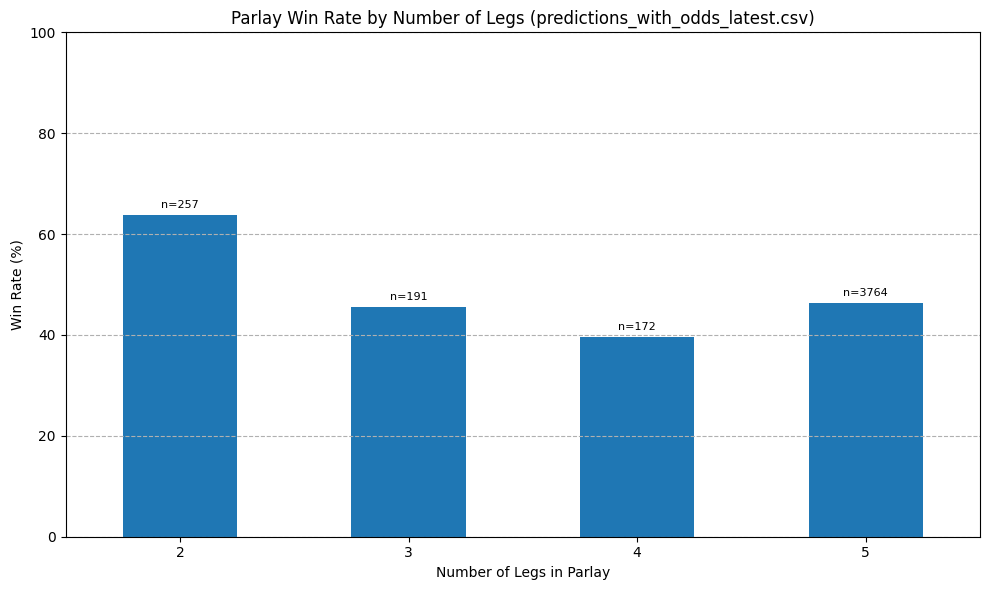

In [7]:


print("\n--- Parlay Performance Analysis ---")

if not parlay_results:
    print("No parlay papers were generated based on the specified strategy.")
else:
    df_parlays = pd.DataFrame(parlay_results)
    display(df_parlays.head())

    total_papers = len(df_parlays)
    winning_papers = df_parlays['ParlayWon'].sum()
    win_rate = winning_papers / total_papers if total_papers > 0 else 0

    avg_legs = df_parlays['NumLegs'].mean()
    avg_parlay_prob = df_parlays['ParlayProbability'].mean()

    print(f"\nTotal Parlay Papers Generated: {total_papers}")
    print(f"Winning Parlay Papers: {winning_papers}")
    print(f"Parlay Win Rate: {win_rate:.2%}")
    print(f"Average Legs per Parlay: {avg_legs:.2f}")
    print(f"Average Calculated Parlay Probability: {avg_parlay_prob:.4f}")

    # Plot win rate by number of legs
    if total_papers > 0:
        try:
            plt.figure(figsize=(10, 6))
            win_rate_by_legs = df_parlays.groupby('NumLegs')['ParlayWon'].mean() * 100
            count_by_legs = df_parlays.groupby('NumLegs')['ParlayWon'].count()

            ax = win_rate_by_legs.plot(kind='bar', title=f'Parlay Win Rate by Number of Legs ({EVAL_CSV_FILENAME})')
            plt.ylabel('Win Rate (%)')
            plt.xlabel('Number of Legs in Parlay')
            plt.ylim(0, max(100, win_rate_by_legs.max() * 1.1))
            plt.xticks(rotation=0)
            plt.grid(axis='y', linestyle='--')

            # Add counts
            for i, count in enumerate(count_by_legs):
                 leg_count = win_rate_by_legs.index[i]
                 ax.text(i, win_rate_by_legs.iloc[i] + 1, f'n={count}', ha='center', va='bottom', fontsize=8)

            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Could not generate win rate by legs plot: {e}")
